In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Load the dataset
file_path = "F:\dissertation\dataset.xlsx"

c:\Users\Jasper\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [13]:

data = pd.read_excel(file_path, sheet_name='Sheet1')

# Define the independent variables (all sectors) and the dependent variable (Sales)
X = data[['Manufacturing', 'Construction', 'Wholesale', 'Retail', 'Information and communication', 'Other services']]
y = data['Sales']

# Add a constant to the predictor variables for the intercept term
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())

# Predict Sales using the model (optional)
predicted_sales = model.predict(X)
data['Predicted_Sales'] = predicted_sales

# Save the predictions to an Excel file (optional)
data.to_excel('ols_sector_predictions.xlsx', index=False)
print("Predictions saved to ols_sector_predictions.xlsx")



                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     27.66
Date:                Sat, 04 Jan 2025   Prob (F-statistic):           0.000403
Time:                        21:40:24   Log-Likelihood:                -56.224
No. Observations:                  13   AIC:                             126.4
Df Residuals:                       6   BIC:                             130.4
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

c:\Users\Jasper\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=13 observations were given.
  return hypotest_fun_in(*args, **kwds)


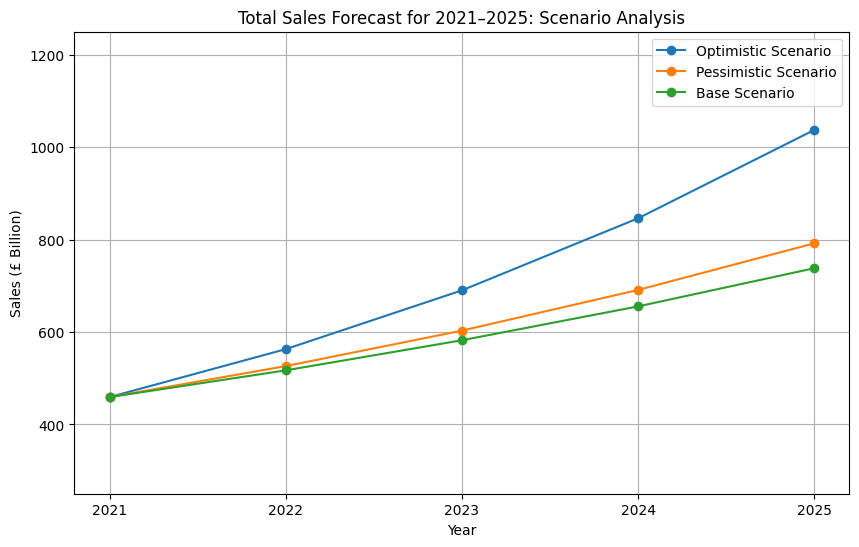

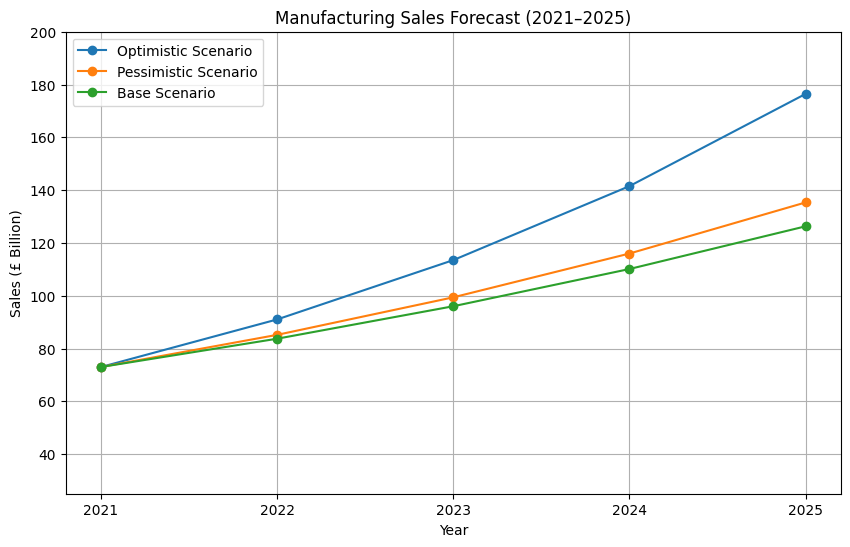

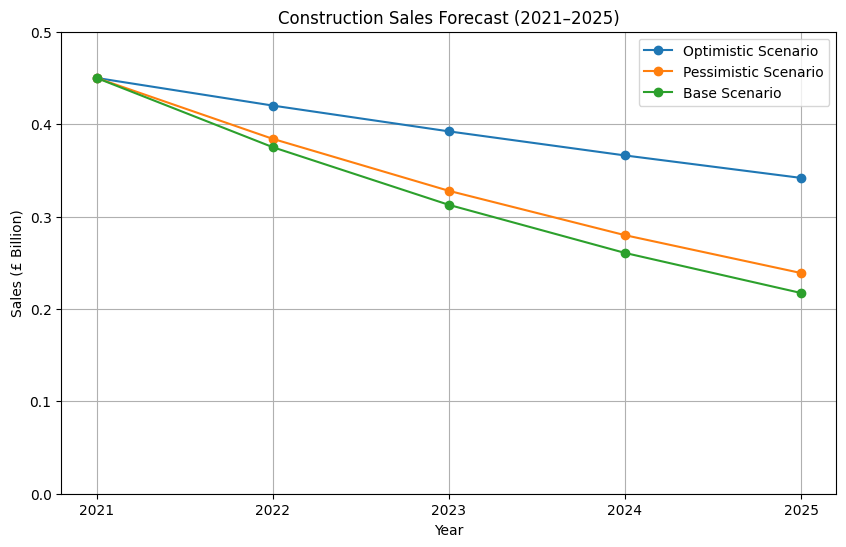

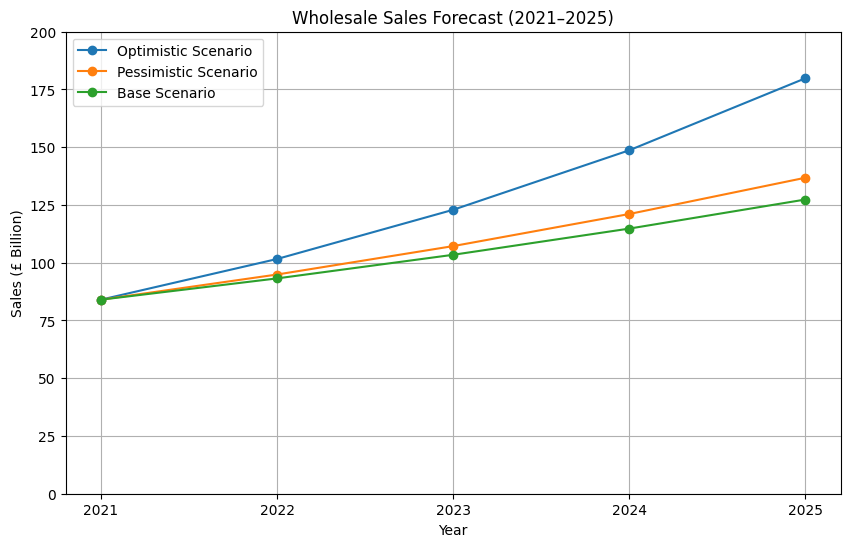

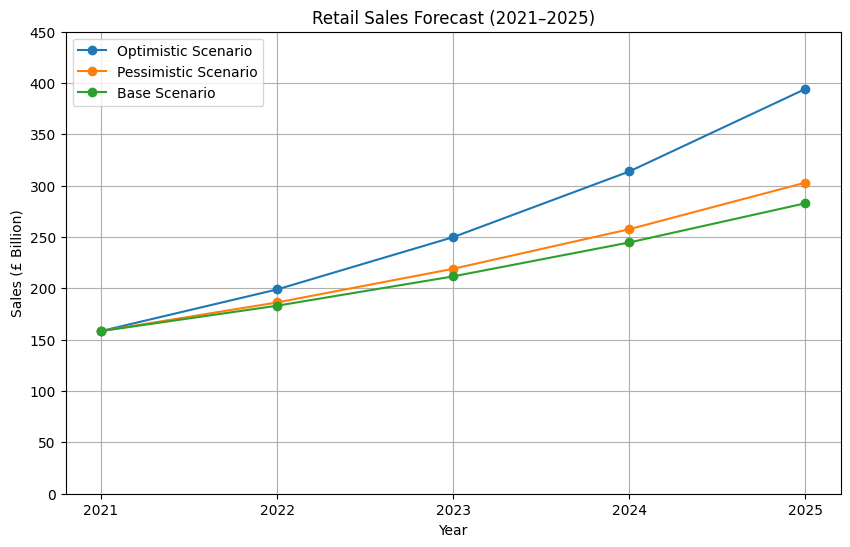

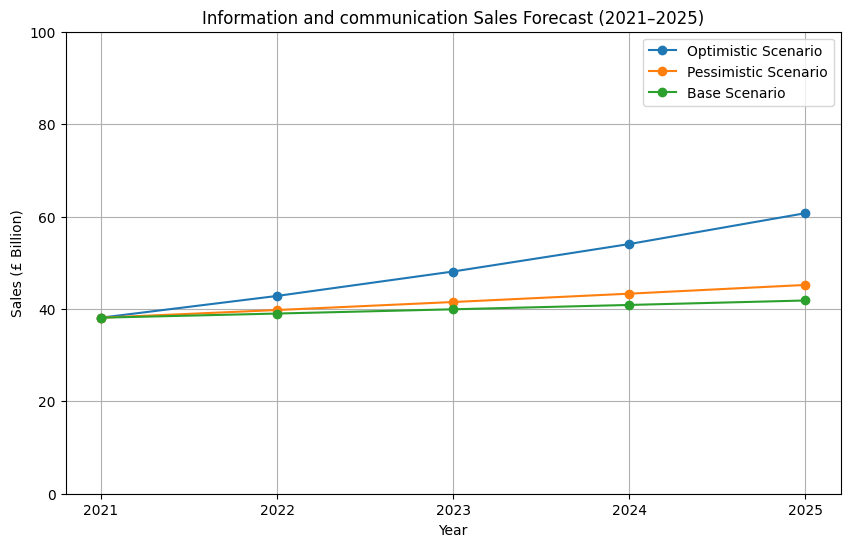

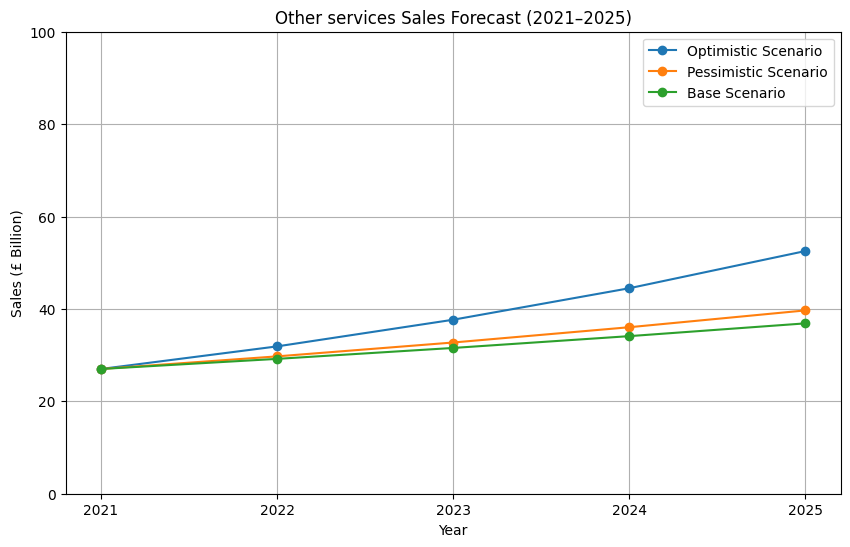

In [8]:
data = pd.read_excel(file_path, sheet_name='Sheet1')

# Calculate CAGR for historical data
def calculate_cagr(start_value, end_value, num_years):
    return ((end_value / start_value) ** (1 / num_years) - 1) * 100

# Prepare historical data
historical_years = data['Year'].values
historical_sales = data.set_index('Year')
start_year, end_year = historical_years[0], historical_years[-1]

# Calculate CAGR for each column
cagr_results = {
    col: calculate_cagr(historical_sales.loc[start_year, col],
                        historical_sales.loc[end_year, col],
                        end_year - start_year)
    for col in historical_sales.columns
}

# Define growth rates for scenarios
growth_rates = {
    "Optimistic": {col: cagr + 10 for col, cagr in cagr_results.items()},
    "Pessimistic": {col: cagr + 2 for col, cagr in cagr_results.items()},
    "Base": cagr_results
}

# Forecasting for 2021-2025
future_years = np.arange(2021, 2026)
forecast_results = {}

for scenario, rates in growth_rates.items():
    forecast_results[scenario] = {}
    for col in historical_sales.columns:
        last_value = historical_sales.loc[end_year, col]
        forecast_results[scenario][col] = [
            last_value * ((1 + rates[col] / 100) ** (year - end_year))
            for year in future_years
        ]

# Convert results to DataFrames
forecast_dfs = {
    scenario: pd.DataFrame(data, index=future_years, columns=historical_sales.columns)
    for scenario, data in forecast_results.items()
}

# Visualization
industries = ['Sales', 'Manufacturing', 'Construction', 'Wholesale', 'Retail',
              'Information and communication', 'Other services']

# Define custom Y-axis limits for specific industries
y_axis_limits = {
    'Sales': (250, 1250),
    'Manufacturing': (25, 200),
    'Construction': (0, 0.5),
    'Wholesale': (0, 200),
    'Retail': (0, 450),
    'Information and communication': (0, 100),
    'Other services': (0, 100)
}

for industry in industries:
    plt.figure(figsize=(10, 6))
    for scenario, df in forecast_dfs.items():
        plt.plot(future_years, df[industry], marker='o', label=f"{scenario} Scenario")
    
    if industry == 'Sales':  
        plt.title('Total Sales Forecast for 2021–2025: Scenario Analysis')
        plt.ylabel('Total Sales (£ Million)')  
    else:
        plt.title(f'{industry} Sales Forecast (2021–2025)')
        #plt.ylabel(f'Sales in (£ billion)') 
    
    plt.xlabel('Year')
    plt.ylabel(f'Sales (£ Billion)')
    plt.xticks(future_years) 
    if industry in y_axis_limits:
        plt.ylim(y_axis_limits[industry])
    plt.grid(True)
    plt.legend()
    plt.show()



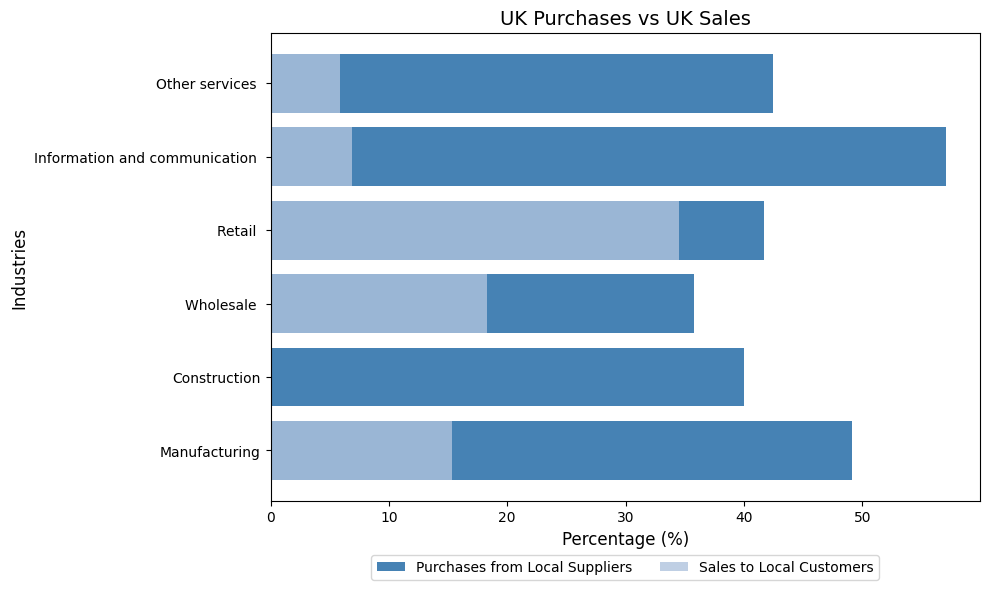

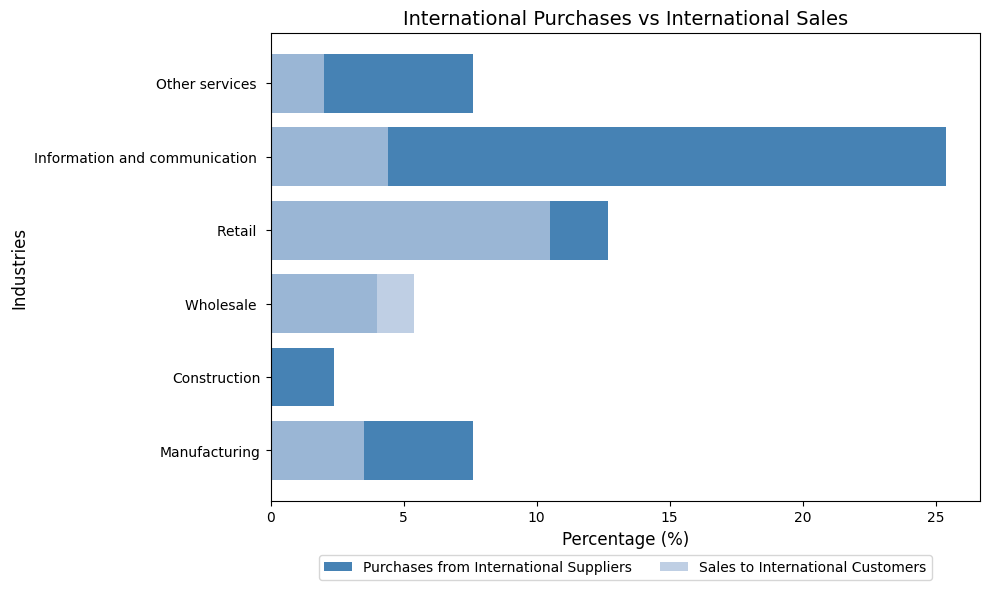

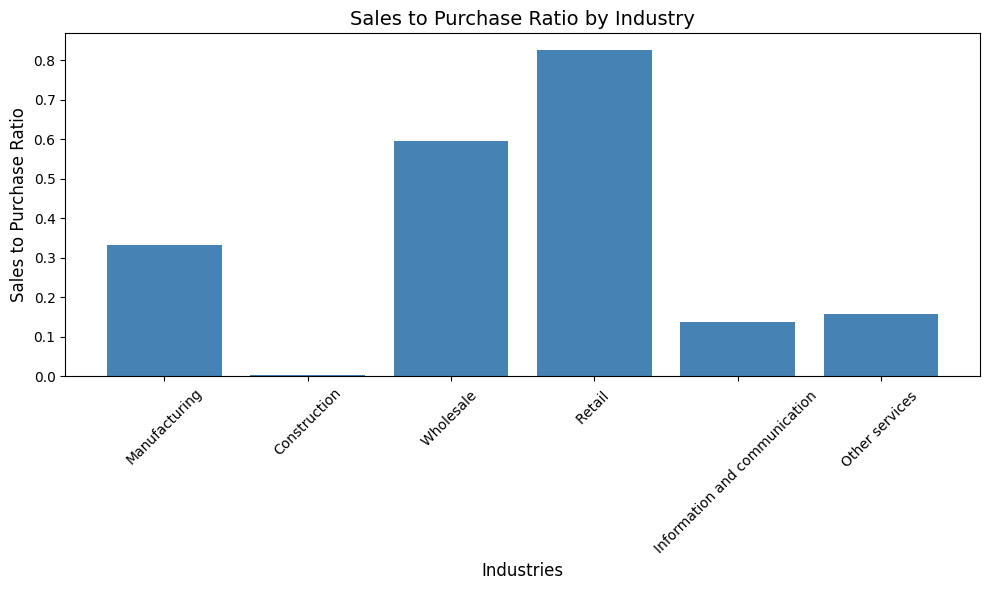

In [8]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = "F:\dissertation\dataset.xlsx"
sheet2_data = pd.read_excel(file_path, sheet_name='Sheet2')

# Step 1: Calculate comparison metrics
# Inside vs Outside Ratios
sheet2_data['Inside Purchase to Sales Ratio'] = (
    sheet2_data['Businesses purchasing from suppliers located in the UK (%)'] /
    sheet2_data['Businesses with sales to customers located in the UK (%)']
)
sheet2_data['Outside Purchase to Sales Ratio'] = (
    sheet2_data['Businesses purchasing from suppliers located outside the UK (%)'] /
    sheet2_data['Businesses with sales to customers located outside the UK (%)']
)

# Sales-to-Purchase Ratio
sheet2_data['Sales to Purchase Ratio'] = (
    (sheet2_data['Businesses with sales to customers located in the UK (%)'] +
     sheet2_data['Businesses with sales to customers located outside the UK (%)']) /
    (sheet2_data['Businesses purchasing from suppliers located in the UK (%)'] +
     sheet2_data['Businesses purchasing from suppliers located outside the UK (%)'])
)

# Visualization 1: Horizontal Bar Chart for Inside UK Purchases vs Inside UK Sales
plt.figure(figsize=(10, 6))
plt.barh(sheet2_data['Industries'], sheet2_data['Businesses purchasing from suppliers located in the UK (%)'], 
         color='#4682B4', label='Purchases from Local Suppliers')
plt.barh(sheet2_data['Industries'], sheet2_data['Businesses with sales to customers located in the UK (%)'], 
         color='#B0C4DE', alpha=0.8, label='Sales to Local Customers', left=0)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Industries', fontsize=12)
plt.title('UK Purchases vs UK Sales', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.savefig('horizontal_bar_inside_uk.png')  # Save for dashboard
plt.show()

# Visualization 2: Horizontal Bar Chart for Outside UK Purchases vs Outside UK Sales
plt.figure(figsize=(10, 6))
plt.barh(sheet2_data['Industries'], sheet2_data['Businesses purchasing from suppliers located outside the UK (%)'], 
         color='#4682B4', label='Purchases from International Suppliers')
plt.barh(sheet2_data['Industries'], sheet2_data['Businesses with sales to customers located outside the UK (%)'], 
         color='#B0C4DE', alpha=0.8, label='Sales to International Customers', left=0)
plt.xlabel('Percentage (%)', fontsize=12)
plt.ylabel('Industries', fontsize=12)
plt.title('International Purchases vs International Sales', fontsize=14)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.savefig('horizontal_bar_outside_uk.png')  # Save for dashboard
plt.show()

# Visualization 3: Bar Chart for Sales-to-Purchase Ratio
plt.figure(figsize=(10, 6))
plt.bar(sheet2_data['Industries'], sheet2_data['Sales to Purchase Ratio'], color='#4682B4')
plt.xlabel('Industries', fontsize=12)
plt.ylabel('Sales to Purchase Ratio', fontsize=12)
plt.title('Sales to Purchase Ratio by Industry', fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('sales_to_purchase_ratio_chart.png')  # Save for dashboard
plt.show()

# Save updated dataset with new metrics to CSV
sheet2_data.to_csv('comparison_analysis_industry_data.csv', index=False)


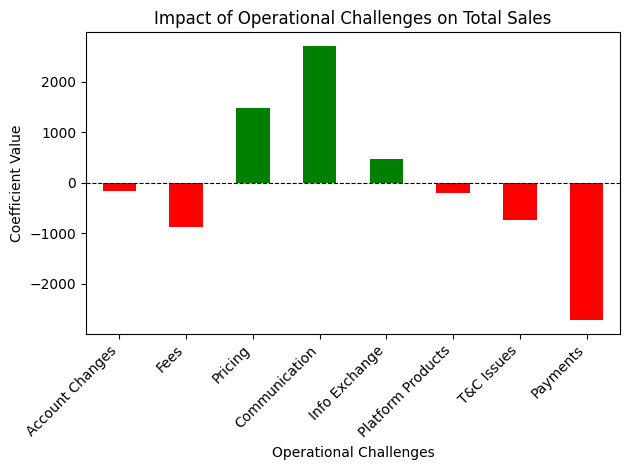

                               OLS Regression Results                              
Dep. Variable:     Total Sales (£ billion)   R-squared:                       1.000
Model:                                 OLS   Adj. R-squared:                    nan
Method:                      Least Squares   F-statistic:                       nan
Date:                     Wed, 01 Jan 2025   Prob (F-statistic):                nan
Time:                             22:48:38   Log-Likelihood:                 159.64
No. Observations:                        6   AIC:                            -307.3
Df Residuals:                            0   BIC:                            -308.5
Df Model:                                5                                         
Covariance Type:                 nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

c:\Users\Jasper\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
c:\Users\Jasper\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1794: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
c:\Users\Jasper\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1794: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
c:\Users\Jasper\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1716: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


In [6]:
# Import necessary libraries
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load the dataset
file_path = "F:\dissertation\dataset.xlsx"
sheet_name = 'Sheet4'  # Specify the correct sheet name
data = pd.ExcelFile(file_path).parse(sheet_name)

# Clean column names
data.columns = [col.strip() for col in data.columns]

# Select relevant columns for regression
relevant_columns = [
    'Changes to your account/product listings by the platform',
    'Fees and commissions',
    'Product Pricing',
    'Communication difficulties',
    'Difficulties with information exchange',
    'Sale of similar products by the platform itself',
    'Issues relating to the terms and conditions',
    'The processing of payments and refunds',
    'Sales in UK \n(£ billion)',
    'Sales outside UK \n(£ billion)'
]
analysis_data = data[relevant_columns].dropna()

# Add Total Sales column
analysis_data['Total Sales (£ billion)'] = (
    analysis_data['Sales in UK \n(£ billion)'] +
    analysis_data['Sales outside UK \n(£ billion)']
)

# Define independent variables (X) and dependent variable (y)
X = analysis_data.drop(columns=[
    'Sales in UK \n(£ billion)', 
    'Sales outside UK \n(£ billion)', 
    'Total Sales (£ billion)'
])
y = analysis_data['Total Sales (£ billion)']

# Simplify variable names for the x-axis
simplified_labels = {
    'Changes to your account/product listings by the platform': 'Account Changes',
    'Fees and commissions': 'Fees',
    'Product Pricing': 'Pricing',
    'Communication difficulties': 'Communication',
    'Difficulties with information exchange': 'Info Exchange',
    'Sale of similar products by the platform itself': 'Platform Products',
    'Issues relating to the terms and conditions': 'T&C Issues',
    'The processing of payments and refunds': 'Payments'
}

# Replace column names in the dataset for easier readability in the chart
X.columns = [simplified_labels.get(col, col) for col in X.columns]
X_with_const = sm.add_constant(X)

# Perform regression analysis
model = sm.OLS(y, X_with_const).fit()

# Visualize coefficients with simplified labels
coefficients = model.params.drop('const')
coefficients.plot(kind='bar', color=['green' if coef > 0 else 'red' for coef in coefficients])
plt.title('Impact of Operational Challenges on Total Sales')
plt.ylabel('Coefficient Value')
plt.xlabel('Operational Challenges')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display the regression summary
print(model.summary())


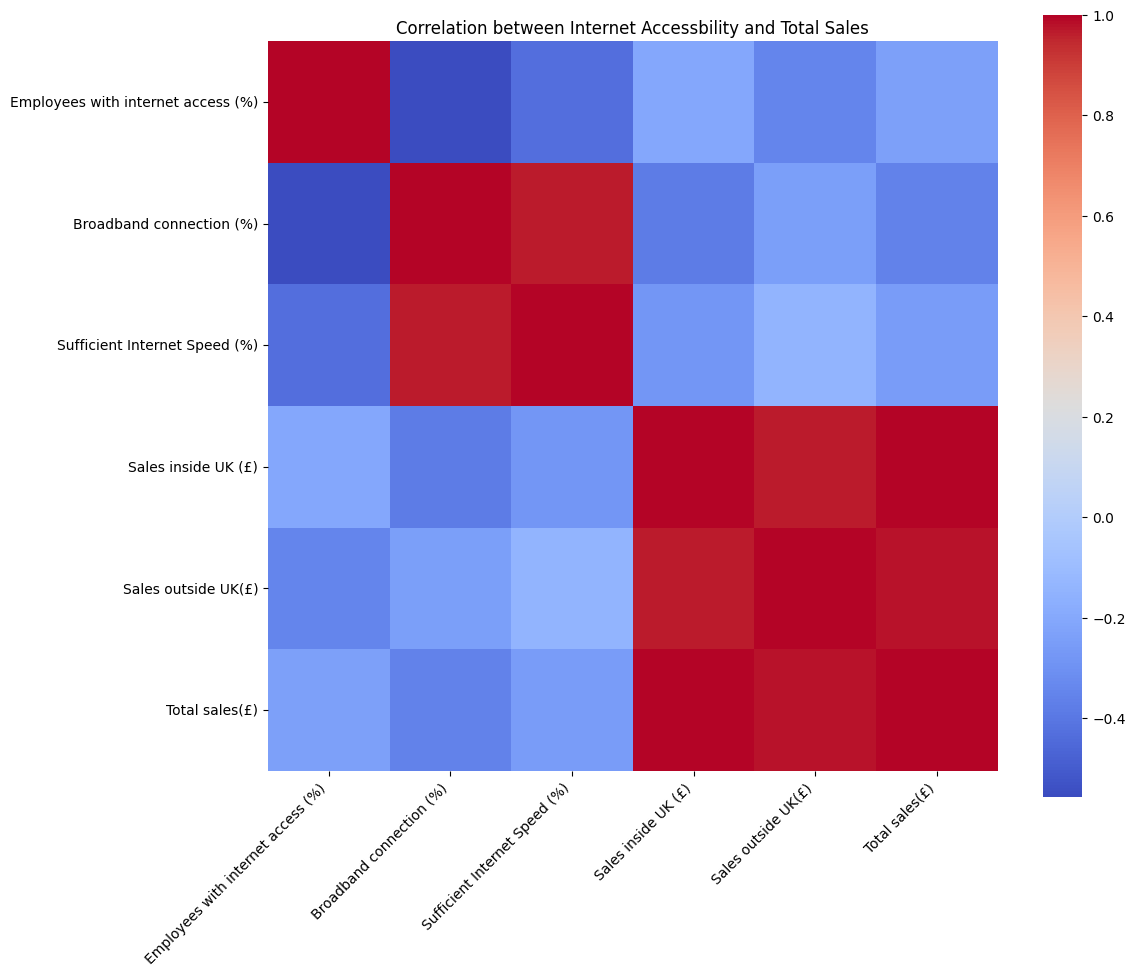

In [11]:
correlation_data = pd.read_excel(file_path, sheet_name="Sheet3") 

# Select only numerical columns for correlation analysis
numerical_data = correlation_data.select_dtypes(include='number')

# Calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# Generate and visualize the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", cbar=True, square=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.title("Correlation between Internet Accessbility and Total Sales") 
plt.show()
